# Test leveling

In [1]:
data_path = r"C:/Users/ggjh246/OneDrive - University of Leeds/Code/playNano_testdata/save-2025.05.20-12.57.06.187.h5-jpk"
from playnano.io.loader import load_afm_stack
afm_stack = load_afm_stack(data_path, channel = "height_trace")

(28, 512, 512)


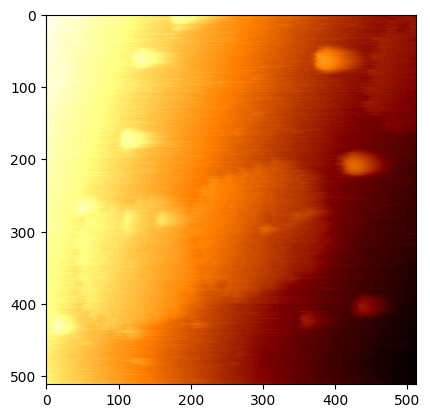

In [2]:
from matplotlib import pyplot as plt

plt.imshow(afm_stack[5], cmap="afmhot")
print(afm_stack.data.shape)

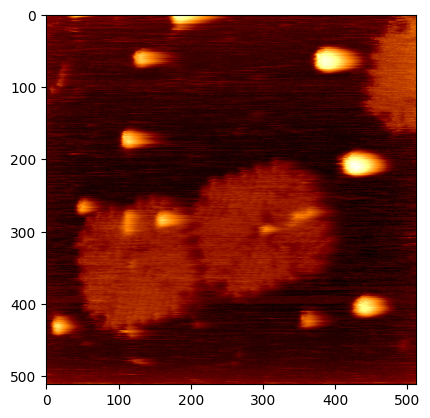

In [3]:
from pnanolocz_lib import level_auto, level, level_weighted

frames = afm_stack.n_frames
frame_ind = range(0, frames)

plane_levelled = level.apply_level(afm_stack.data, 2, 2, "plane")
plt.imshow(plane_levelled[5], cmap="afmhot")


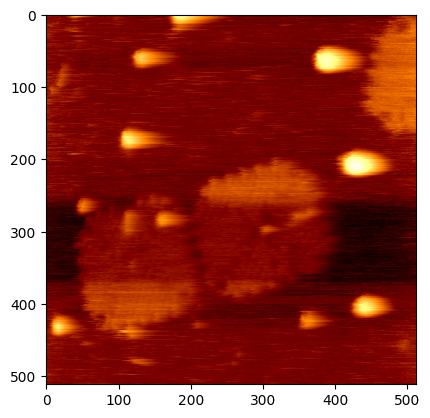

In [4]:
levelled = level.apply_level(plane_levelled, 1, 0, "med_line",)
plt.imshow(levelled[5], cmap="afmhot")


In [5]:
auto_leveled = level_auto.apply_level_auto(afm_stack.data, "multi-plane-otsu")

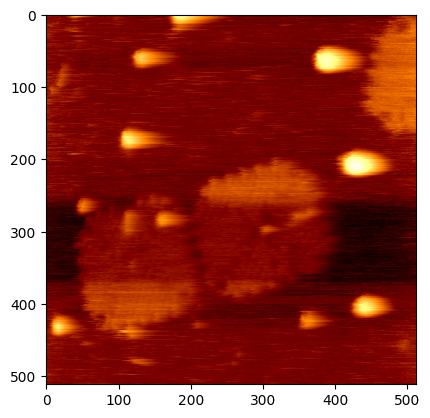

In [6]:
plt.imshow(auto_leveled[5], cmap="afmhot")

In [7]:
from pnanolocz_lib.thresholder import thresholder
mask_hist = thresholder(plane_levelled, 'histogram', limits = (0.2, 100),invert = False)

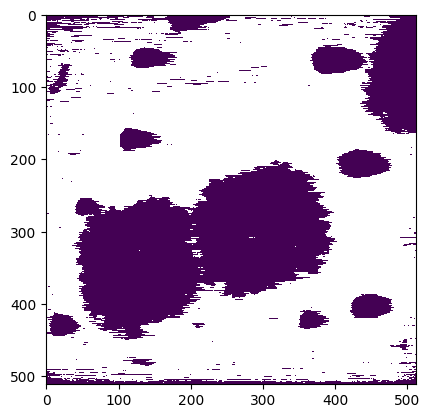

In [8]:
plt.imshow(mask_hist[5], interpolation= 'none')

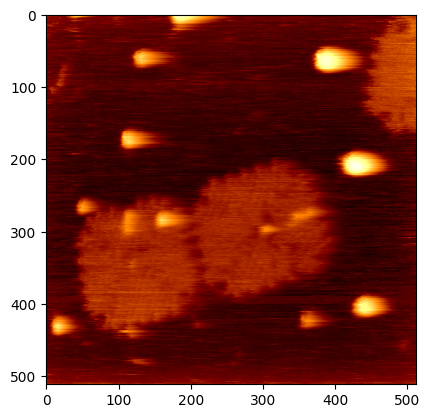

In [18]:
from pnanolocz_lib.level_weighted import apply_level_weighted
lev_weight = apply_level_weighted(plane_levelled, 1, 1, "smed_line", mask=mask_hist)
plt.imshow(lev_weight[5], cmap="afmhot")

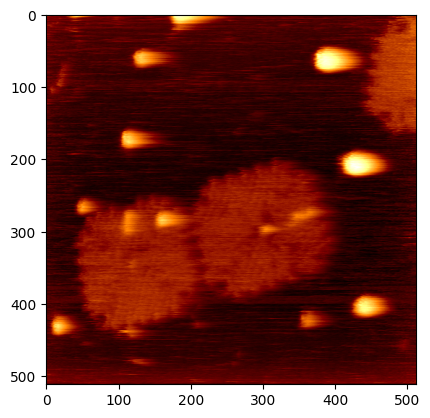

In [10]:
masked_line_levelled = level.apply_level(plane_levelled, 1, 0, "line", mask_hist)
plt.imshow(masked_line_levelled[5], cmap="afmhot")

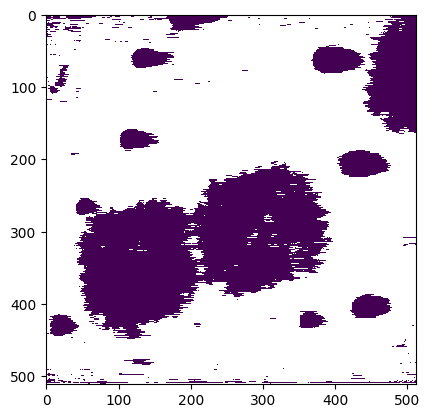

In [11]:
hist2 = thresholder(masked_line_levelled, "histogram", limits=(0.4,100), invert=False)
plt.imshow(hist2[5],  interpolation= 'none')

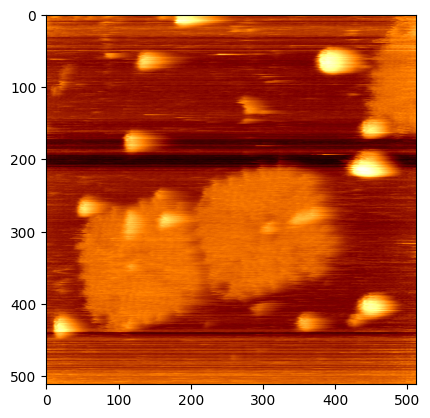

In [12]:
maksed_linemed_levelled = level.apply_level(masked_line_levelled, 1, 0, "med_line", mask_hist)
plt.imshow(maksed_linemed_levelled[1], cmap="afmhot")

In [14]:
mask_hist2 =thresholder(maksed_linemed_levelled, 'histogram', limits= (0.5,100), invert=False)

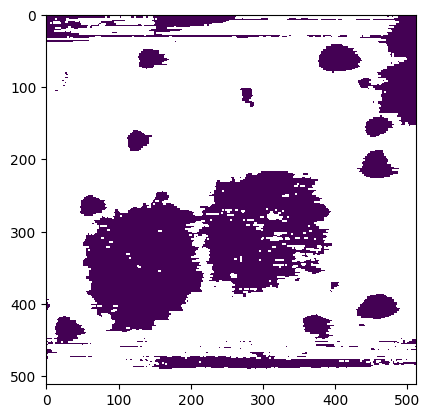

In [15]:
mask_hist2 = thresholder(maksed_linemed_levelled, 'histogram', limits = (0.5,100),invert = False)
plt.imshow(mask_hist2[0])

In [16]:
manual_levelled = level.apply_level(masked_plane_levelled, 1, 0, "line", mask_hist2)
plt.imshow(manual_levelled[0], cmap="afmhot")

NameError: name 'masked_plane_levelled' is not defined

In [17]:
from pnanolocz_lib.level import get_background

In [ ]:
bg = get_background(afm_stack.data, 1, 0, 'med_line')

In [ ]:
plt.imshow(bg[0])